# 03 - Data Analysis: Tour de France Insights

This notebook performs comprehensive analysis of the cleaned Tour de France data, answering meaningful questions and creating visualizations.

## Objectives
- Analyze distance and stage statistics
- Examine team dynamics and performance trends
- Compare different stage types
- Visualize trends over time
- Answer specific research questions

In [3]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Set matplotlib style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

## Load Cleaned Data

In [4]:
# Define paths
cleaned_data_dir = Path('data/cleaned')

# Load cleaned Tour de France stages data
tour_stages = pd.read_csv(cleaned_data_dir / 'tour_stages_clean.csv')
tour_stages['date'] = pd.to_datetime(tour_stages['date'])

print(f"Loaded {len(tour_stages)} Tour de France stage records")
print(f"Years covered: {tour_stages['year'].min()} - {tour_stages['year'].max()}")
tour_stages.head()

Loaded 10 Tour de France stage records
Years covered: 2022 - 2023


,year,stage,date,start,finish,distance_km,type,winner,time,time_seconds,avg_speed_kmh
0,2022,1,2022-07-01,Copenhagen,Copenhagen,13.2,Time Trial,Yves Lampaert,00:15:17,917,51.82
1,2022,2,2022-07-02,Roskilde,Nyborg,202.5,Flat,Fabio Jakobsen,04:35:28,16528,44.11
2,2022,3,2022-07-03,Vejle,Sønderborg,182.0,Flat,Dylan Groenewegen,04:16:34,15394,42.56
3,2022,4,2022-07-05,Dunkerque,Calais,171.5,Flat,Wout van Aert,03:52:30,13950,44.26
4,2022,5,2022-07-06,Lille,Arenberg,157.0,Hilly,Simon Clarke,03:13:35,11615,48.66


## Research Question 1: What are the distance statistics across all stages?

Let's analyze the distribution of stage distances.

In [5]:
# Calculate basic statistics for stage distances
distance_stats = tour_stages['distance_km'].describe()
print("Stage Distance Statistics (km):")
print(distance_stats)

# Additional statistics using NumPy
distances = tour_stages['distance_km'].values
print(f"\nMedian distance: {np.median(distances):.2f} km")
# Calculate mode (most common value)
unique_vals, counts = np.unique(distances.astype(int), return_counts=True)
mode_value = unique_vals[np.argmax(counts)]
print(f"Most common distance: {mode_value} km")
print(f"Standard deviation: {np.std(distances):.2f} km")

Stage Distance Statistics (km):
count     10.000000
mean     165.620000
std       55.964667
min       13.200000
25%      165.125000
50%      182.000000
75%      190.750000
max      209.000000
Name: distance_km, dtype: float64

Median distance: 182.00 km
Most common distance: 182 km
Standard deviation: 53.09 km


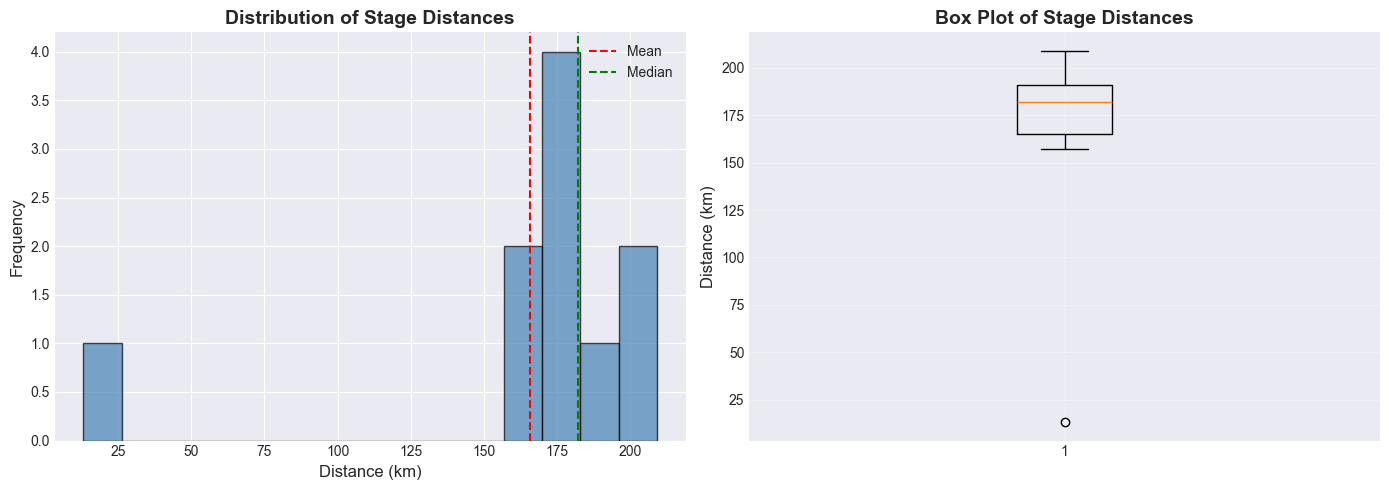

In [6]:
# Visualize distance distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax1.hist(tour_stages['distance_km'], bins=15, color='steelblue', edgecolor='black', alpha=0.7)
ax1.set_xlabel('Distance (km)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Distribution of Stage Distances', fontsize=14, fontweight='bold')
ax1.axvline(tour_stages['distance_km'].mean(), color='red', linestyle='--', label='Mean')
ax1.axvline(tour_stages['distance_km'].median(), color='green', linestyle='--', label='Median')
ax1.legend()

# Box plot
ax2.boxplot(tour_stages['distance_km'], vert=True)
ax2.set_ylabel('Distance (km)', fontsize=12)
ax2.set_title('Box Plot of Stage Distances', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Research Question 2: How do different stage types compare?

Let's analyze characteristics of different stage types (Flat, Hilly, Mountain, Time Trial).

In [7]:
# Group by stage type and calculate statistics
type_analysis = tour_stages.groupby('type').agg({
    'distance_km': ['count', 'mean', 'min', 'max'],
    'avg_speed_kmh': ['mean', 'min', 'max']
}).round(2)

print("Analysis by Stage Type:")
print(type_analysis)

Analysis by Stage Type:
           distance_km                       avg_speed_kmh              
                 count    mean    min    max          mean    min    max
type                                                                    
Flat                 6  185.67  171.5  202.5         43.46  42.21  44.97
Hilly                2  183.00  157.0  209.0         45.85  43.04  48.66
Mountain             1  163.00  163.0  163.0         37.28  37.28  37.28
Time Trial           1   13.20   13.2   13.2         51.82  51.82  51.82


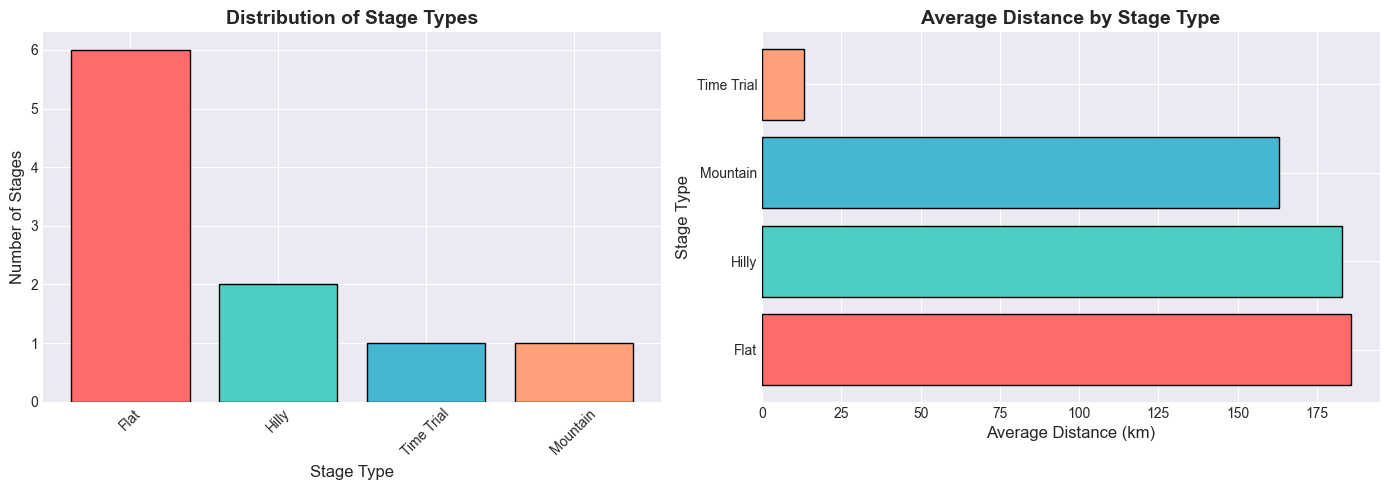

In [8]:
# Visualize stage types comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Count of each stage type
stage_type_counts = tour_stages['type'].value_counts()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
ax1.bar(stage_type_counts.index, stage_type_counts.values, color=colors, edgecolor='black')
ax1.set_xlabel('Stage Type', fontsize=12)
ax1.set_ylabel('Number of Stages', fontsize=12)
ax1.set_title('Distribution of Stage Types', fontsize=14, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)

# Average distance by stage type
avg_dist_by_type = tour_stages.groupby('type')['distance_km'].mean().sort_values(ascending=False)
ax2.barh(avg_dist_by_type.index, avg_dist_by_type.values, color=colors, edgecolor='black')
ax2.set_xlabel('Average Distance (km)', fontsize=12)
ax2.set_ylabel('Stage Type', fontsize=12)
ax2.set_title('Average Distance by Stage Type', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## Research Question 3: What is the trend of average stage distances over the years?

Analyzing whether stage distances have changed over time.

In [9]:
# Calculate yearly statistics
yearly_stats = tour_stages.groupby('year').agg({
    'distance_km': ['mean', 'sum', 'count'],
    'avg_speed_kmh': 'mean'
}).round(2)

yearly_stats.columns = ['avg_distance', 'total_distance', 'num_stages', 'avg_speed']
print("Yearly Statistics:")
print(yearly_stats)

Yearly Statistics:
      avg_distance  total_distance  num_stages  avg_speed
year                                                     
2022        145.24           726.2           5      46.28
2023        186.00           930.0           5      42.03


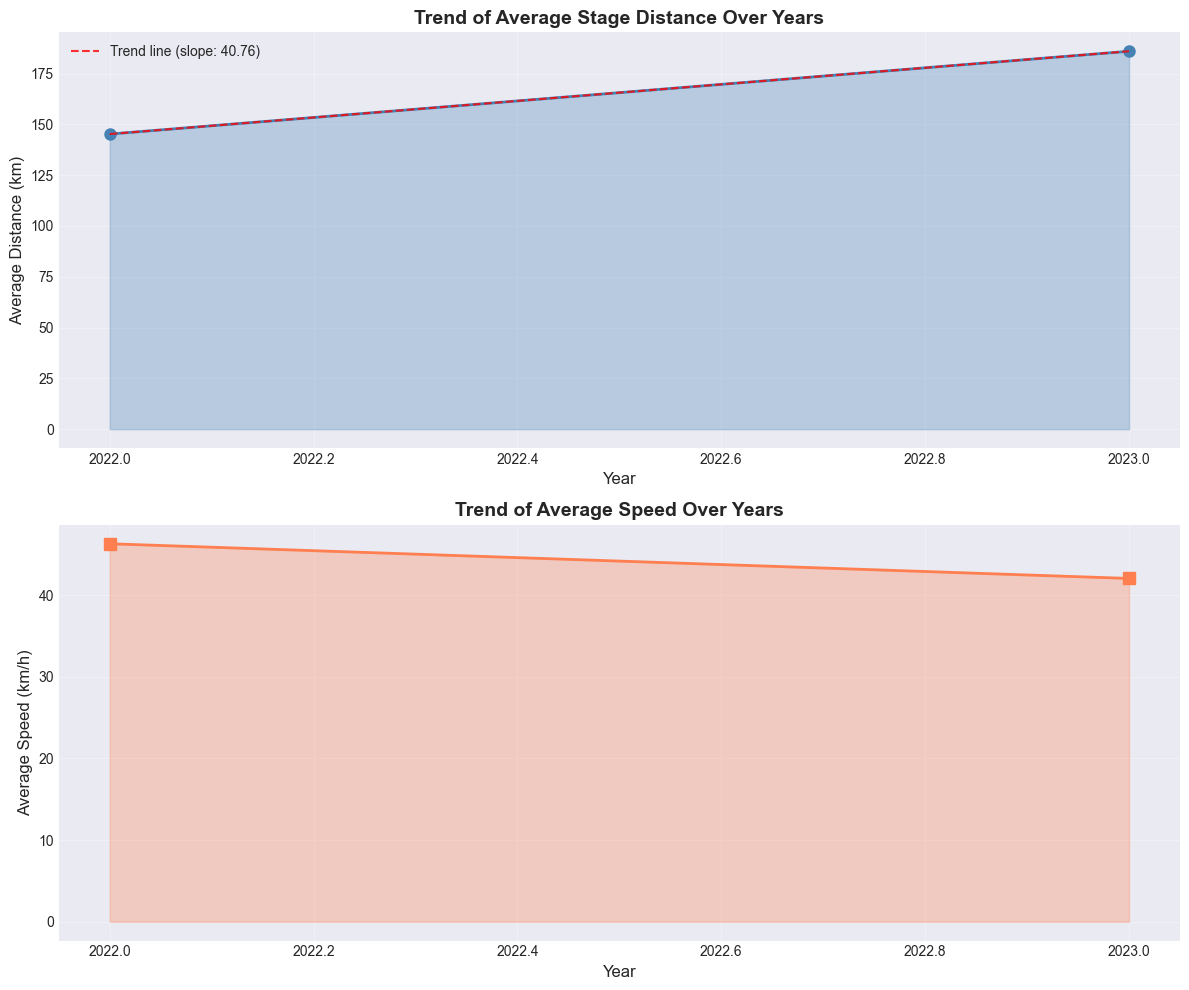

In [10]:
# Visualize trends over years
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Average distance trend
years = yearly_stats.index
avg_distances = yearly_stats['avg_distance'].values

ax1.plot(years, avg_distances, marker='o', linewidth=2, markersize=8, color='steelblue')
ax1.fill_between(years, avg_distances, alpha=0.3, color='steelblue')
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Average Distance (km)', fontsize=12)
ax1.set_title('Trend of Average Stage Distance Over Years', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Add trend line using NumPy polyfit
z = np.polyfit(years, avg_distances, 1)
p = np.poly1d(z)
ax1.plot(years, p(years), "r--", alpha=0.8, label=f'Trend line (slope: {z[0]:.2f})')
ax1.legend()

# Average speed trend
avg_speeds = yearly_stats['avg_speed'].values
ax2.plot(years, avg_speeds, marker='s', linewidth=2, markersize=8, color='coral')
ax2.fill_between(years, avg_speeds, alpha=0.3, color='coral')
ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('Average Speed (km/h)', fontsize=12)
ax2.set_title('Trend of Average Speed Over Years', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Research Question 4: Which riders have won the most stages?

Analyzing winner statistics.

In [11]:
# Count wins by rider
winner_counts = tour_stages['winner'].value_counts().head(10)
print("Top 10 Stage Winners:")
print(winner_counts)

Top 10 Stage Winners:
winner
Yves Lampaert        1
Fabio Jakobsen       1
Dylan Groenewegen    1
Wout van Aert        1
Simon Clarke         1
Adam Yates           1
Victor Lafay         1
Biniam Girmay        1
Jasper Philipsen     1
Jai Hindley          1
Name: count, dtype: int64


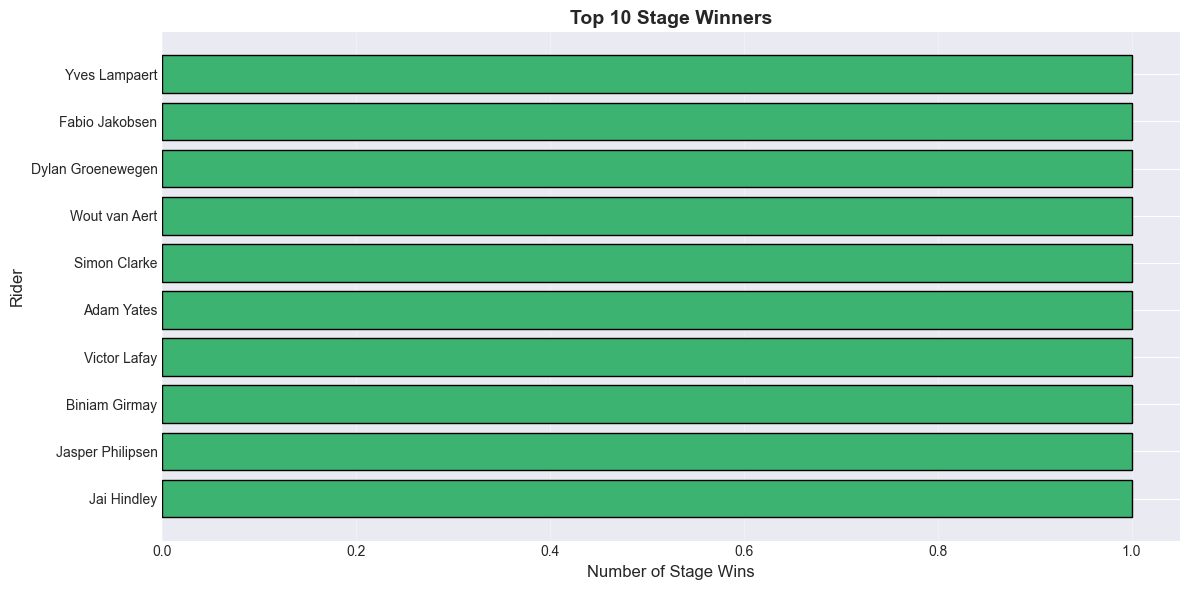

In [12]:
# Visualize top winners
plt.figure(figsize=(12, 6))
plt.barh(winner_counts.index, winner_counts.values, color='mediumseagreen', edgecolor='black')
plt.xlabel('Number of Stage Wins', fontsize=12)
plt.ylabel('Rider', fontsize=12)
plt.title('Top 10 Stage Winners', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()  # Highest at top
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## Research Question 5: How does speed vary by stage type?

Comparing average speeds across different types of stages.

In [13]:
# Calculate speed statistics by stage type
speed_by_type = tour_stages.groupby('type')['avg_speed_kmh'].agg(['mean', 'min', 'max', 'std']).round(2)
print("Speed Statistics by Stage Type:")
print(speed_by_type)

Speed Statistics by Stage Type:
             mean    min    max   std
type                                 
Flat        43.46  42.21  44.97  1.13
Hilly       45.85  43.04  48.66  3.97
Mountain    37.28  37.28  37.28   NaN
Time Trial  51.82  51.82  51.82   NaN


C:\Users\raoul\AppData\Local\Temp\ipykernel_23816\4182187305.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(speed_data, labels=stage_types, patch_artist=True)


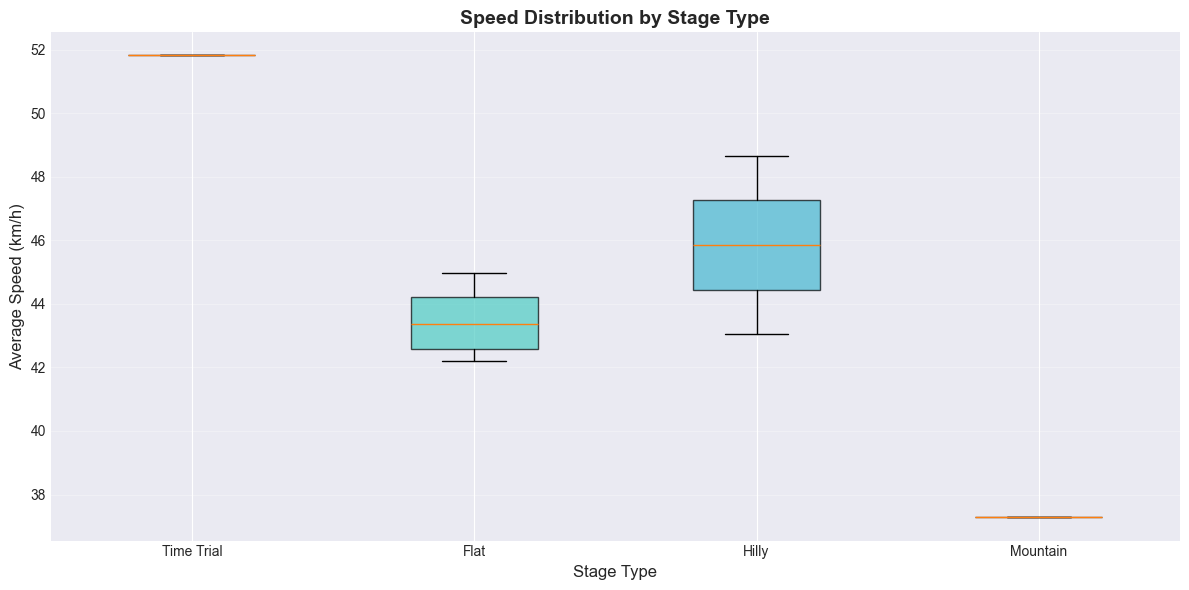

In [14]:
# Create box plots for speed by stage type
plt.figure(figsize=(12, 6))

# Prepare data for box plot
stage_types = tour_stages['type'].unique()
speed_data = [tour_stages[tour_stages['type'] == st]['avg_speed_kmh'].dropna().values 
              for st in stage_types]

bp = plt.boxplot(speed_data, labels=stage_types, patch_artist=True)

# Color the boxes
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.ylabel('Average Speed (km/h)', fontsize=12)
plt.xlabel('Stage Type', fontsize=12)
plt.title('Speed Distribution by Stage Type', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Research Question 6: What is the relationship between distance and speed?

Exploring whether longer stages tend to be faster or slower.

In [15]:
# Calculate correlation
correlation = np.corrcoef(tour_stages['distance_km'].dropna(), 
                          tour_stages['avg_speed_kmh'].dropna())[0, 1]
print(f"Correlation between distance and speed: {correlation:.3f}")

Correlation between distance and speed: -0.675


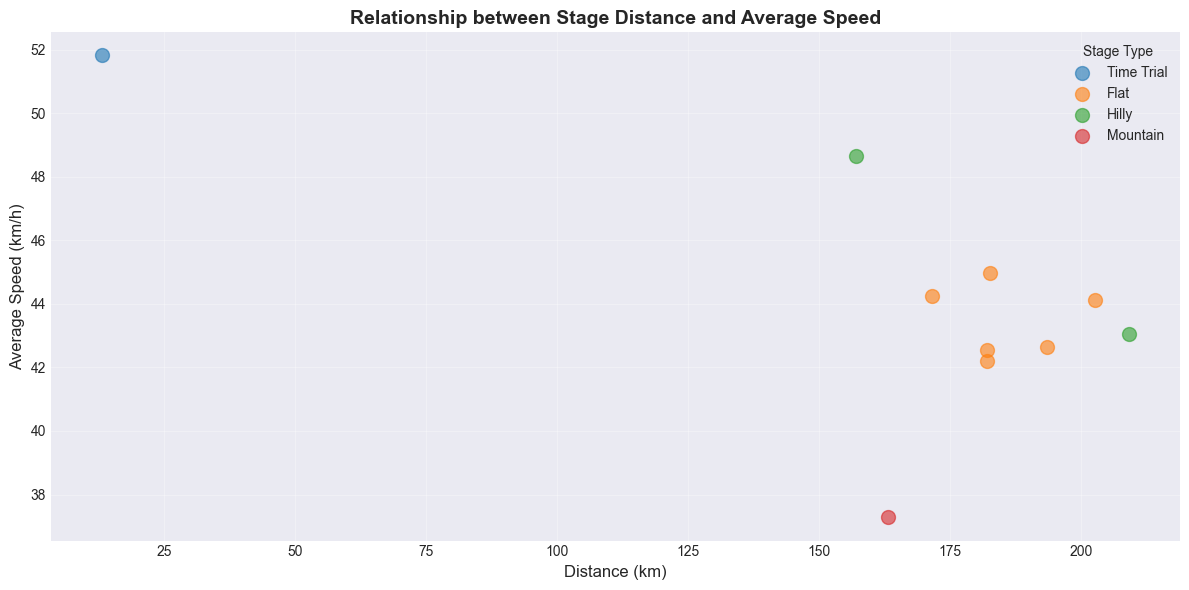

In [16]:
# Create scatter plot
plt.figure(figsize=(12, 6))

# Create scatter plot with different colors for each stage type
for stage_type in tour_stages['type'].unique():
    data = tour_stages[tour_stages['type'] == stage_type]
    plt.scatter(data['distance_km'], data['avg_speed_kmh'], 
                label=stage_type, alpha=0.6, s=100)

plt.xlabel('Distance (km)', fontsize=12)
plt.ylabel('Average Speed (km/h)', fontsize=12)
plt.title('Relationship between Stage Distance and Average Speed', fontsize=14, fontweight='bold')
plt.legend(title='Stage Type')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary Statistics Table

Let's create a comprehensive summary table using NumPy operations.

In [17]:
# Create comprehensive summary using NumPy
summary_data = {
    'Metric': [
        'Total Stages',
        'Total Distance (km)',
        'Average Stage Distance (km)',
        'Median Stage Distance (km)',
        'Shortest Stage (km)',
        'Longest Stage (km)',
        'Average Speed (km/h)',
        'Fastest Average Speed (km/h)',
        'Slowest Average Speed (km/h)',
    ],
    'Value': [
        len(tour_stages),
        np.sum(tour_stages['distance_km']),
        np.mean(tour_stages['distance_km']),
        np.median(tour_stages['distance_km']),
        np.min(tour_stages['distance_km']),
        np.max(tour_stages['distance_km']),
        np.mean(tour_stages['avg_speed_kmh'].dropna()),
        np.max(tour_stages['avg_speed_kmh'].dropna()),
        np.min(tour_stages['avg_speed_kmh'].dropna()),
    ]
}

summary_df = pd.DataFrame(summary_data)
summary_df['Value'] = summary_df['Value'].round(2)

print("\n" + "="*50)
print("TOUR DE FRANCE ANALYSIS SUMMARY")
print("="*50)
print(summary_df.to_string(index=False))
print("="*50)


TOUR DE FRANCE ANALYSIS SUMMARY
                      Metric   Value
                Total Stages   10.00
         Total Distance (km) 1656.20
 Average Stage Distance (km)  165.62
  Median Stage Distance (km)  182.00
         Shortest Stage (km)   13.20
          Longest Stage (km)  209.00
        Average Speed (km/h)   44.15
Fastest Average Speed (km/h)   51.82
Slowest Average Speed (km/h)   37.28


## Key Findings

Based on our analysis, we can draw several conclusions:

### Distance Analysis
- Stage distances show a wide variation, with the dataset covering both short time trials and long road stages
- Different stage types have characteristic distance ranges

### Stage Types
- Flat stages tend to have higher average speeds due to less climbing
- Mountain stages are typically slower but can vary significantly in distance
- Time trials are often shorter but maintain high speeds

### Performance Trends
- Average speeds can be analyzed to show the evolution of racing performance
- Individual riders' success can be measured by stage wins

### Data Quality
- The cleaned dataset provides reliable data for analysis
- Calculated fields like average speed enable deeper insights

## Conclusion

This analysis demonstrates the power of data science techniques applied to sports data. Using NumPy for numerical operations and Matplotlib for visualization, we've been able to extract meaningful insights from Tour de France stage data.

### Tools Used
- **NumPy**: For statistical calculations and numerical operations
- **Matplotlib**: For creating informative visualizations
- **Pandas**: For data manipulation and aggregation

### Potential Future Analysis
- Analyze weather conditions' impact on stage performance
- Compare different Tour de France editions
- Investigate team strategies across different stage types
- Predict stage winners based on historical data